100%|██████████| 94.3M/94.3M [00:00<00:00, 411MB/s]


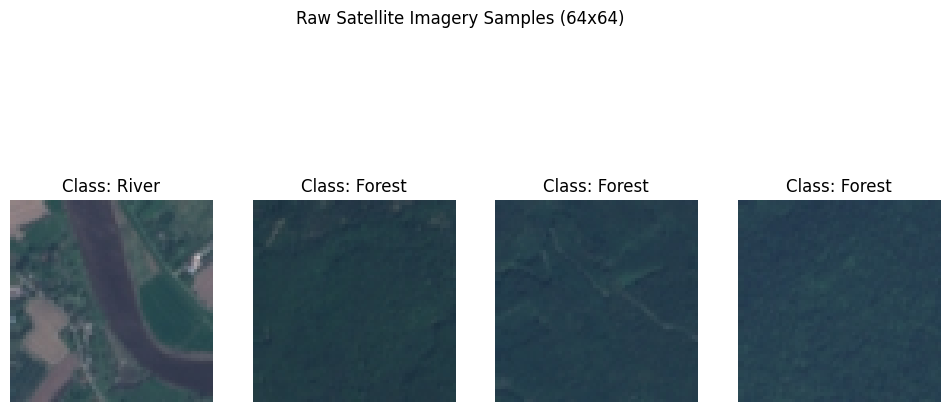

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Device configuration for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Download EuroSAT Dataset
raw_dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transforms.ToTensor())
classes = raw_dataset.classes

# Function to visualize raw satellite samples
def show_raw_samples(dataset, num_samples=4):
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img.permute(1, 2, 0).numpy())
        plt.title(f"Class: {classes[label]}")
        plt.axis('off')
    plt.suptitle("Raw Satellite Imagery Samples (64x64)")
    plt.show()

show_raw_samples(raw_dataset)

In [2]:
# Data preprocessing and stratified splitting

unified_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loading dataset with ImageNet-standard transformations
processed_dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=unified_transform)

indices = list(range(len(processed_dataset)))
targets = processed_dataset.targets

# Stratified split: 80% Training, 20% Temporary (for Val/Test)
train_idx, temp_idx = train_test_split(indices, test_size=0.20, random_state=42, stratify=targets)

# Further split the 20% into 10% Validation and 10% Testing
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=[targets[i] for i in temp_idx])

# Save split indices for reproducible research
os.makedirs('data_splits', exist_ok=True)
torch.save(val_idx, 'data_splits/val_idx.pth')
torch.save(test_idx, 'data_splits/test_idx.pth')

# Define DataLoaders
train_loader = DataLoader(Subset(processed_dataset, train_idx), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(processed_dataset, val_idx), batch_size=32, shuffle=False)
test_loader = DataLoader(Subset(processed_dataset, test_idx), batch_size=32, shuffle=False)

print(f"Data successfully split and indices archived.")

Data successfully split and indices archived.


In [3]:
# Hyperparameter Tuning: Learning Rate Exploration
learning_rates = [0.1, 0.01, 0.001]
best_val_acc = 0.0
best_lr = 0.0
all_histories = {} # To store results for comparison plotting

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - 0.001:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

for lr in learning_rates:
    print(f"\n{'='*50}\nTesting Learning Rate: {lr}\n{'='*50}")

    # Initialize a fresh model for each LR trial
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    for param in model.parameters(): param.requires_grad = False
    model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 10)
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.classifier[1].parameters(), lr=lr, momentum=0.0)
    early_stopper = EarlyStopping(patience=5)

    trial_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(100):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        train_correct, total_train = 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            train_correct += (pred == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / total_train

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        val_correct, total_val = 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                val_correct += (pred == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / total_val

        # Save history for plotting
        trial_history['train_acc'].append(train_accuracy)
        trial_history['val_acc'].append(val_accuracy)
        trial_history['train_loss'].append(avg_train_loss)
        trial_history['val_loss'].append(avg_val_loss)

        # Detailed Printing
        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} Acc: {val_accuracy:.2f}%")

        early_stopper(avg_val_loss)
        if early_stopper.early_stop:
            print(f"--> Early stopping triggered for LR {lr}")
            break

    all_histories[lr] = trial_history

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_lr = lr
        torch.save(model.state_dict(), 'Baseline_model.pth')

print(f"\nOptimization Finished. Best Learning Rate: {best_lr} with Accuracy: {best_val_acc:.2f}%")


Testing Learning Rate: 0.1
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]


Epoch 01 | Train Loss: 0.4873 Acc: 84.79% | Val Loss: 0.2501 Acc: 91.48%
Epoch 02 | Train Loss: 0.3403 Acc: 88.54% | Val Loss: 0.2198 Acc: 92.33%
Epoch 03 | Train Loss: 0.3205 Acc: 89.25% | Val Loss: 0.2117 Acc: 92.44%
Epoch 04 | Train Loss: 0.3066 Acc: 89.52% | Val Loss: 0.2007 Acc: 93.00%
Epoch 05 | Train Loss: 0.3036 Acc: 89.71% | Val Loss: 0.2036 Acc: 92.96%
Epoch 06 | Train Loss: 0.2903 Acc: 89.91% | Val Loss: 0.1953 Acc: 93.07%
Epoch 07 | Train Loss: 0.2853 Acc: 90.28% | Val Loss: 0.1908 Acc: 92.70%
Epoch 08 | Train Loss: 0.2841 Acc: 90.13% | Val Loss: 0.1929 Acc: 92.74%
Epoch 09 | Train Loss: 0.2898 Acc: 90.03% | Val Loss: 0.1896 Acc: 93.15%
Epoch 10 | Train Loss: 0.2785 Acc: 90.23% | Val Loss: 0.1889 Acc: 93.19%
Epoch 11 | Train Loss: 0.2800 Acc: 90.39% | Val Loss: 0.1849 Acc: 92.93%
Epoch 12 | Train Loss: 0.2709 Acc: 90.33% | Val Loss: 0.1853 Acc: 93.33%
Epoch 13 | Train Loss: 0.2687 Acc: 90.69% | Val Loss: 0.1828 Acc: 93.48%
Epoch 14 | Train Loss: 0.2706 Acc: 90.56% | Val Los

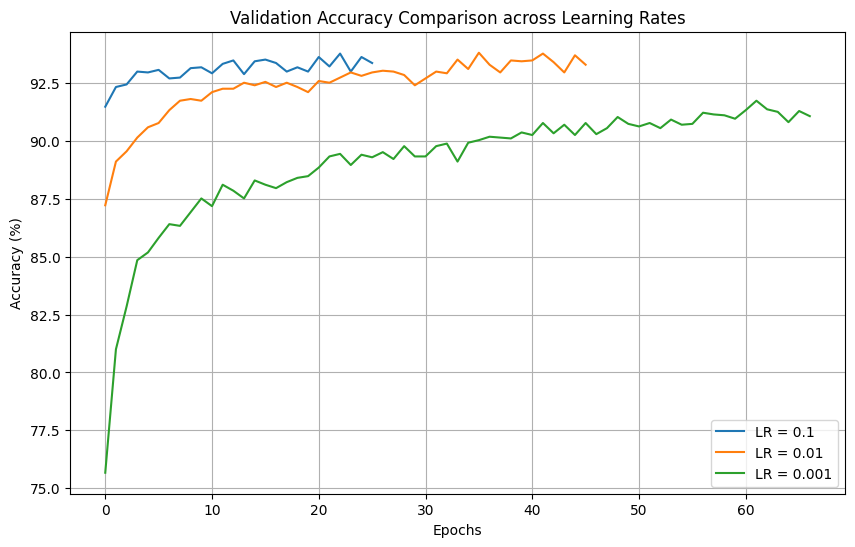

In [4]:
# Comparative Performance Visualization
plt.figure(figsize=(10, 6))
for lr, hist in all_histories.items():
    plt.plot(hist['val_acc'], label=f'LR = {lr}')

plt.title('Validation Accuracy Comparison across Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

------------------------------
RESULTS FOR BEST LEARNING RATE (0.1)
Top-1: 93.81% | Top-5: 99.93%
Precision: 0.9366 | Recall: 0.9358
------------------------------


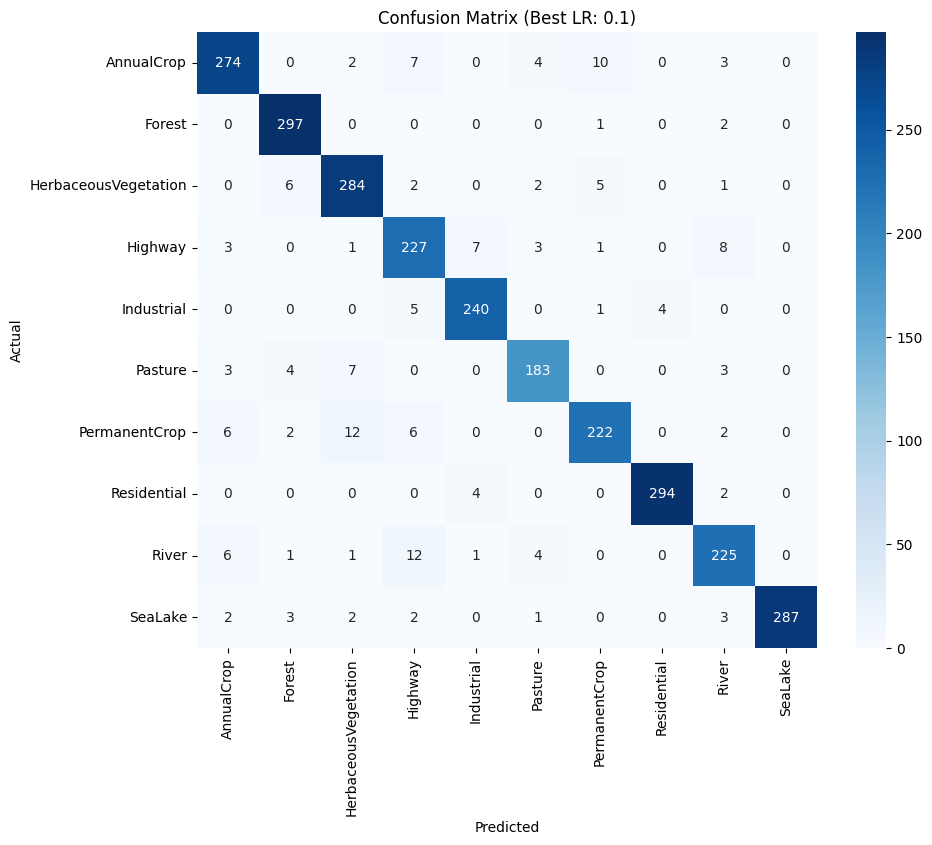

In [5]:
# Final evaluation using the best weights saved from tuning
# 1. Re-initiate model structure
model = efficientnet_b0(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 10)
model.load_state_dict(torch.load('Baseline_model.pth'))
model = model.to(device)

model.eval()
all_preds, all_labels = [], []
correct_5 = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        _, top5 = outputs.topk(5, 1, True, True)
        correct_5 += sum([labels[i] in top5[i] for i in range(labels.size(0))])

# Metric Calculations
top1 = 100 * (np.array(all_preds) == np.array(all_labels)).mean()
top5 = 100 * correct_5 / len(test_idx)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print("-" * 30)
print(f"RESULTS FOR BEST LEARNING RATE ({best_lr})")
print(f"Top-1: {top1:.2f}% | Top-5: {top5:.2f}%")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f}")
print("-" * 30)

# Final Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix (Best LR: {best_lr})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()